# How can we control the increasing number of accidents in New York?

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import base64


## Introduction

**Business Context.** The city of New York has seen a rise in the number of accidents on the roads in the city. They would like to know if the number of accidents have increased in the last few weeks. For all the reported accidents, they have collected details for each accident and have been maintaining records for the past year and a half (from January 2018 to August 2019). 

The city has contracted you to build visualizations that would help them identify patterns in accidents, which would help them take preventive actions to reduce the number of accidents in the future. They have certain parameters like borough, time of day, reason for accident, etc. Which they care about and which they would like to get specific information on.

**Business Problem.** Your task is to format the given data and provide visualizations that would answer the specific questions the client has, which are mentioned below.

**Analytical Context.** You are given a CSV file (stored in the already created ```data``` folder) containing details about each accident like date, time, location of the accident, reason for the accident, types of vehicles involved, injury and death count, etc. The delimiter in the given CSV file is `;` instead of the default `,`. You will be performing the following tasks on the data:

1. Extract additional borough data stored in a JSON file
2. Read, transform, and prepare data for visualization
3. Perform analytics and construct visualizations of the data to identify patterns in the dataset
        
The client has a specific set of questions they would like to get answers to. You will need to provide visualizations to accompany these:

1. How have the number of accidents fluctuated over the past year and a half? Have they increased over the time?
2. For any particular day, during which hours are accidents most likely to occur?
3. Are there more accidents on weekdays than weekends?
4. What are the accidents count-to-area ratio per borough? Which boroughs have disproportionately large numbers of accidents for their size?
5. For each borough, during which hours are accidents most likely to occur?
6. What are the top 5 causes of accidents in the city? 
7. What types of vehicles are most involved in accidents per borough?
8. What types of vehicles are most involved in deaths?

**Note:** To solve this extended case, please read the function docstrings **very carefully**. They contain information that you will need! Also, please don't include `print()` statements inside your functions (they will most likely produce an error in the test cells).

## Fetching the relevant data

The client has requested analysis of the accidents-to-area ratio for boroughs. Borough data is stored in a JSON file in the ```data``` folder (this file was created using data from [Wikipedia](https://en.wikipedia.org/wiki/Boroughs_of_New_York_City)).

### Question

Use the function ```json.load()``` to load the file ```borough_data.json``` as a dictionary.

**Answer.** One possible solution is given below:

In [24]:
with open('borough_data.json') as f:
    borough_data=json.load(f)
borough_data



{'the bronx': {'name': 'the bronx', 'population': 1471160.0, 'area': 42.1},
 'brooklyn': {'name': 'brooklyn', 'population': 2648771.0, 'area': 70.82},
 'manhattan': {'name': 'manhattan', 'population': 1664727.0, 'area': 22.83},
 'queens': {'name': 'queens', 'population': 2358582.0, 'area': 108.53},
 'staten island': {'name': 'staten island',
  'population': 479458.0,
  'area': 58.37}}

### Question

Similarly, use the `pandas` function ```read_csv()``` to load the file ```accidents.csv``` as a DataFrame. Name this DataFrame ```df```. 

**Answer.** One possible solution is given below:

In [25]:
with open('accident.csv') as f:
    df=pd.read_csv(f, delimiter=';')

## Overview of the data

Let's go through the columns present in the DataFrame:

In [26]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.dtypes



# here in the above line of code i have used 
# str.strip() to remove any space before or after the coloumn name 
# str.lower() to convert the column name to lowercase
# str.replace() i have seperated the coloumn names with  '-' 

date                              object
time                              object
borough                           object
zip_code                         float64
latitude                         float64
longitude                        float64
on_street_name                    object
number_of_pedestrians_injured      int64
number_of_pedestrians_killed       int64
number_of_cyclist_injured          int64
number_of_cyclist_killed           int64
number_of_motorist_injured         int64
number_of_motorist_killed          int64
contributing_factor_vehicle_1     object
contributing_factor_vehicle_2     object
contributing_factor_vehicle_3     object
contributing_factor_vehicle_4     object
contributing_factor_vehicle_5     object
collision_id                       int64
vehicle_type_code_1               object
vehicle_type_code_2               object
vehicle_type_code_3               object
vehicle_type_code_4               object
vehicle_type_code_5               object
dtype: object

We have the following columns:

1. **BOROUGH**: The borough in which the accident occurred
2. **COLLISION_ID**: A unique identifier for this collision
3. **CONTRIBUTING FACTOR VEHICLE (1, 2, 3, 4, 5)**: Reasons for the accident
4. **CROSS STREET NAME**: Nearest cross street to the location of the accident
5. **DATE**: Date of the accident
6. **TIME**: Time of the accident
7. **LATITUDE**: Latitude of the accident
8. **LONGITUDE**: Longitude of the accident
9. **NUMBER OF (CYCLISTS, MOTORISTS, PEDESTRIANS) INJURED**: Injuries by category
10. **NUMBER OF (CYCLISTS, MOTORISTS, PEDESTRIANS) KILLED**: Deaths by category
11. **ON STREET NAME**: Street where the accident occurred
13. **VEHICLE TYPE CODE (1, 2, 3, 4, 5)**: Types of vehicles involved in the accident
14. **ZIP CODE**: Zip code of the accident location

### Exercise 1

Since 2014, New York City has been implementing a road safety plan named [Vision Zero](https://www1.nyc.gov/content/visionzero/pages/). It aims to reduce the number of traffic deaths to *zero* by the end of 2024. The plan is creating new and enhancing current safety measures, some of these include:

<ul>
A. Automated pedestrian detection<br>
B. Road safety audits at high risk locations<br>
C. Expansion in the cycle track network<br>
D. Targeted education and awareness initiatives<br>
E. Creation of pedestrian refuge islands<br>
F. Launch Integrated Data-Driven Speed Reducer Program (speed humps & speed cushions)<br>
</ul>

Which of these initiatives could directly benefit from an analysis of the data provided?

**Note:** In this notebook, whenever you are asked to write text, use the cell below the question cell to write your answer there. If you write in the same cell as the question, your answer will not be recorded.


**Your answer here**.

## Answering the client's questions

Let's go ahead and answer each of the client's questions.

### Exercise 2

#### 2.1

Group the available accident data by month.

**Hint**: You may find the `pandas` functions [```pd.to_datetime()```](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) and [```dt.to_period()```](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html) useful.

here i have converted the datatype of date from Object to Datetime

here i have converted date column into a month time period to analysis the accidents in particular month

here i did groupby on month_period so that all the accidents on each month will form a group 
.size() will count the no.of rows in each group 
df.groupby('month_period').size() will return a series 
.reset_index(name='total_accidents') this code converts the series into a dataframe and saved it as a column name 'total_accidents '



In [27]:
def ex_2(df):

    """
    Group accidents by month
    
    Arguments:
    `df`: A pandas DataFrame
    
    Outputs:
    `monthly_accidents`: The grouped Series
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution

    #return monthly_accidents

#############################################################

df['date'] = pd.to_datetime(df['date'])
#print(df[['date']])

df['month_period'] = df['date'].dt.to_period('M')
#print(df[['month_period']])

monthly_accidents = df.groupby('month_period').size().reset_index(name='total_accidents')
print(monthly_accidents)


   month_period  total_accidents
0       2018-01            11735
1       2018-02            10395
2       2018-03            12519
3       2018-04            11679
4       2018-05            13438
5       2018-06            13314
6       2018-07            12787
7       2018-08            12644
8       2018-09            12425
9       2018-10            13336
10      2018-11            12447
11      2018-12            12479
12      2019-01            11000
13      2019-02            10310
14      2019-03            11482
15      2019-04            10833
16      2019-05            12642
17      2019-06            12577
18      2019-07            12014
19      2019-08             8466


#### 2.2
##### 2.2.1

Generate a line plot of accidents over time.


here plt.plot(monthly_accidents['month_period'].dt.to_timestamp() converts the period object to timestamp for analysis in pandas
marker='o') Adds a small circular dot at each data point for clarity
Ploting month_period on (x-axis) vs total_accidents on (y-axis) and connecting points with a line and showing dots at each point.”

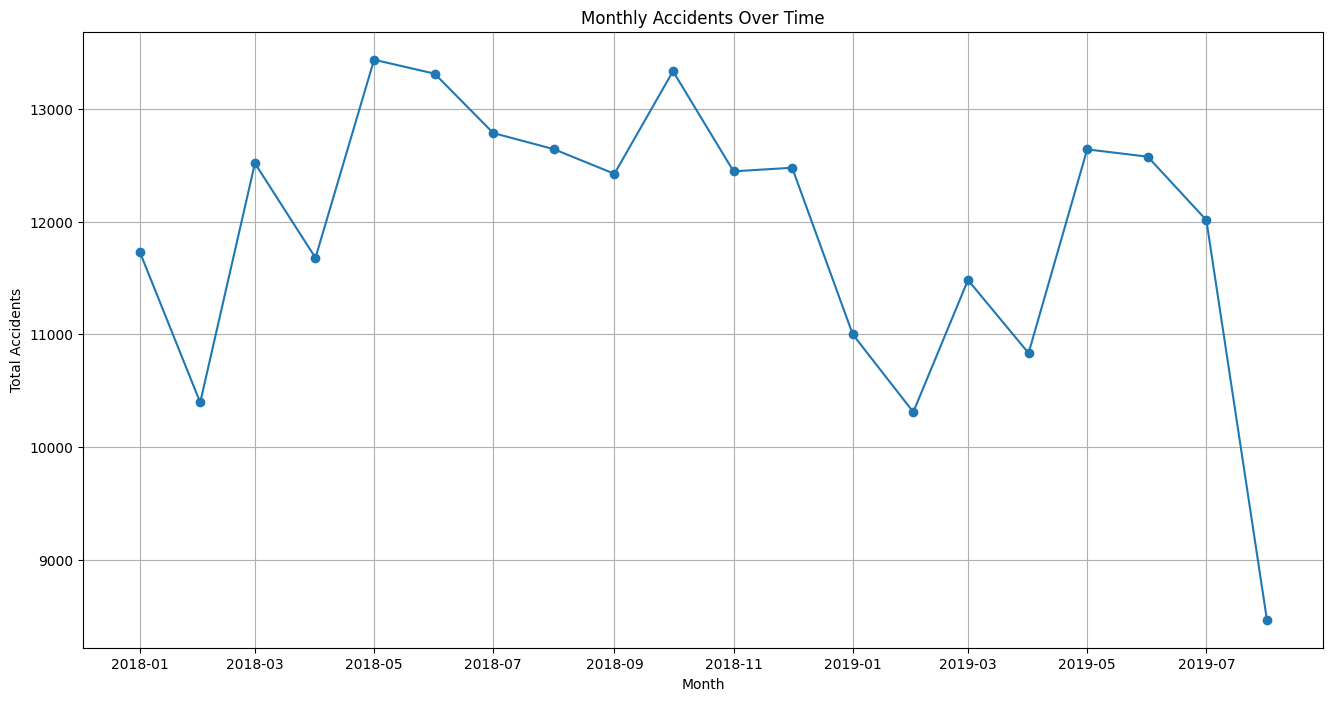

In [28]:
# YOUR CODE HERE
#ßraise NotImplementedError() # Remove this line when you enter your solution


plt.figure(figsize=(16,8))
plt.plot(monthly_accidents['month_period'].dt.to_timestamp(), monthly_accidents['total_accidents'], marker='o')
plt.title('Monthly Accidents Over Time')
plt.xlabel('Month')
plt.ylabel('Total Accidents')
plt.grid(True)
plt.show()


##### 2.2.2

Has the number of accidents increased over the past year and a half?



.sort_values('month_period') this will sort the data according to month_period so that i can get the old and latest month data just by using index number
.iloc[0] gives integer position of first row ( old data )
.iloc[-1] gives integer position of last row ( latest data )

In [29]:

monthly_accidents = monthly_accidents.sort_values('month_period')

start_value = monthly_accidents['total_accidents'].iloc[0]
end_value = monthly_accidents['total_accidents'].iloc[-1]

percent = ((end_value - start_value) / start_value) * 100

print(f"Accidents changed by {percent:.2f}% over the last 1.5 years.")


Accidents changed by -27.86% over the last 1.5 years.


**Your answer here**.

### Exercise 3

From the plot above, which months seem to have the least number of accidents? What do you think are the reasons behind this?


In [30]:


most_accidents_month = monthly_accidents.loc[monthly_accidents['total_accidents'].idxmax()]
print(f"Most number of accidents are in {most_accidents_month}")

least_accidents_month = monthly_accidents.loc[monthly_accidents['total_accidents'].idxmin()]
print(f"Least number of accidents are in {least_accidents_month}")


Most number of accidents are in month_period       2018-05
total_accidents      13438
Name: 4, dtype: object
Least number of accidents are in month_period       2019-08
total_accidents       8466
Name: 19, dtype: object


**Your answer here**.

From the above plot in the month of 08-2019 we have registered least number of accidents

In [31]:
month = least_accidents_month['month_period'].to_timestamp()

accidents_in_least_month = df[df['date'].dt.to_period('M') == month.to_period('M')]
accidents_in_least_month['on_street_name'].value_counts()


on_street_name
BROADWAY                            62
ATLANTIC AVENUE                     59
LINDEN BOULEVARD                    59
NORTHERN BOULEVARD                  53
3 AVENUE                            53
                                    ..
EAST 221 STREET                      1
64 AVENUE                            1
STADIUM AVENUE                       1
MOORE STREET                         1
BOWNE STREET                         1
Name: count, Length: 1653, dtype: int64

In [32]:
reason_series = pd.concat([
    accidents_in_least_month['contributing_factor_vehicle_1'],
    accidents_in_least_month['contributing_factor_vehicle_2'],
    accidents_in_least_month['contributing_factor_vehicle_3'],
    accidents_in_least_month['contributing_factor_vehicle_4'],
    accidents_in_least_month['contributing_factor_vehicle_5']
])

reason_counts = reason_series.value_counts()
print(reason_counts)


Unspecified                                              8756
Driver Inattention/Distraction                           2698
Failure to Yield Right-of-Way                             646
Following Too Closely                                     575
Backing Unsafely                                          542
Passing Too Closely                                       457
Passing or Lane Usage Improper                            434
Other Vehicular                                           387
Unsafe Lane Changing                                      217
Turning Improperly                                        195
Driver Inexperience                                       166
Traffic Control Disregarded                               160
Unsafe Speed                                              147
Reaction to Uninvolved Vehicle                            109
View Obstructed/Limited                                   108
Alcohol Involvement                                        98
Pedestri

In [33]:
vehicle_type_series = pd.concat([
    accidents_in_least_month['vehicle_type_code_1'],
    accidents_in_least_month['vehicle_type_code_2'],
    accidents_in_least_month['vehicle_type_code_3']
])

vehicle_type_count = vehicle_type_series.value_counts()
print(vehicle_type_count)

Sedan                                  6768
Station Wagon/Sport Utility Vehicle    5701
Taxi                                    617
Pick-up Truck                           523
Box Truck                               437
                                       ... 
UNK                                       1
MINI                                      1
WORK                                      1
rep                                       1
SCHOO                                     1
Name: count, Length: 102, dtype: int64


### Exercise 4

#### 4.1

Create a new column `HOUR` based on the data from the `TIME` column.

**Hint:** You may find the ```dt.hour``` accessor useful.

here i have converted datatype of Time coloumn from object to datetime
then i have created Hour coloumn from time 


In [34]:
def ex_4(df):
    """
    Group accidents by hour of day
    
    Arguments:
    `df`: A pandas DataFrame
    
    Outputs:
    `hourly_accidents`: The grouped Series

    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    
    #return hourly_accidents
#############################################

df['time'] = pd.to_datetime(df['time'])
df['hour']= df['time'].dt.hour
#print(df['time'])

print(df['hour'])


0         12
1         16
2         19
3         13
4         22
          ..
238517    15
238518    14
238519    13
238520    17
238521    16
Name: hour, Length: 238522, dtype: int32


/var/folders/ql/72ttndnx3rl_77y4q5x_g21c0000gn/T/ipykernel_36161/1267803451.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])


#### 4.2
##### 4.2.1
 
Plot a bar graph of the distribution per hour throughout the day.

In [35]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution

hourly_accidents = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(hourly_accidents.index, hourly_count.values, color='skyblue')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.title('Accident Distribution per Hour')
plt.xticks(range(0,24)) 
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()


NameError: name 'hourly_count' is not defined

<Figure size 1200x600 with 0 Axes>

##### 4.2.2
How does the number of accidents vary throughout a single day?


0–3	    Low	Night      fewer vehicles
4–7	    Medium     	   Morning rush hour
8–13	Medium/rush	   Daytime, moderate traffic
14–18	High	       Evening rush hour
19–23	Medium/Low	   Night, fewer vehicles

**Your answer here**.

### Exercise 5

In the above question we have aggregated the number accidents per hour disregarding the date and place of occurrence. What criticism would you give to this approach?



Aggregating only accidents per hour without considering the day, date or location might ignores important variations in the data. Accident patterns will differ between weekdays and weekends, or in between different locations. By disregarding these factors, this approach will give a misleading analytical picture of when accidents are most likely to occur and could lead to incorrect conclusions.

**Your answer here**.

### Exercise 6


#### 6.1

Calculate the number of accidents by day of the week.

**Hint:** You may find the ```dt.weekday``` accessor useful.

here i have created weekday coloumn from time coloumn 
then counted the no.of accidents per day in a week
i have defined the days, ( days_order, fill_value=0 ) this will fill 0 for all the days wich are not in the dataset 

In [ ]:
def ex_6(df):
    """
    Group accidents by day of the week
    
    Arguments:
    `df`: A pandas DataFrame
    
    Outputs:
    `weekday_accidents`: The grouped Series
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    
    #return weekday_accidents
#############################################################

df['weekday'] = df['time'].dt.day_name() 
accidents_by_day = df['weekday'].value_counts()

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
accidents_by_day = accidents_by_day.reindex(days_order, fill_value=0)

print(accidents_by_day)


weekday
Monday            0
Tuesday           0
Wednesday         0
Thursday          0
Friday            0
Saturday     238522
Sunday            0
Name: count, dtype: int64


#### 6.2
##### 6.2.1
Plot a bar graph based on the accidents count by day of the week.

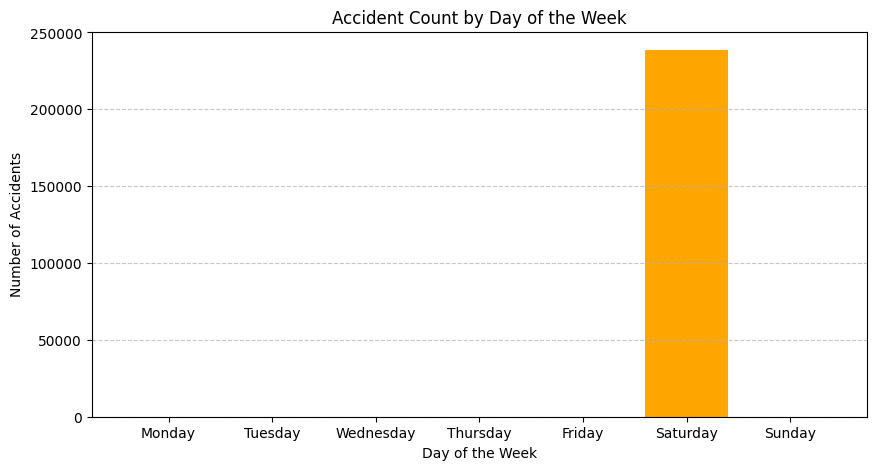

In [ ]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution


plt.figure(figsize=(10,5))
plt.bar(accidents_by_day.index, accidents_by_day.values, color='orange')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.title('Accident Count by Day of the Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


##### 6.2.2

How does the number of accidents vary throughout a single week?


**Your answer here**.

most accidents are happen on Saturday

### Exercise 7

#### 7.1

Calculate the total number of accidents for each borough.

i can also get total no.of accidents for each borough by value_count(), but i used groupby bcz it helps in analysing with multiple columns

In [ ]:
def ex_7_1(df):
    """
    Group accidents by borough
    
    Arguments:
    `df`: A pandas DataFrame
    
    Outputs:
    `boroughs`: The grouped Series
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    
    #return boroughs
###################################################

accidents_by_borough = df.groupby('borough').size().reset_index(name='total_accidents')
print(accidents_by_borough)


         borough  total_accidents
0          BRONX            37709
1       BROOKLYN            76253
2      MANHATTAN            48749
3         QUEENS            67120
4  STATEN ISLAND             8691


#### 7.2
##### 7.2.1

Plot a bar graph of the previous data.

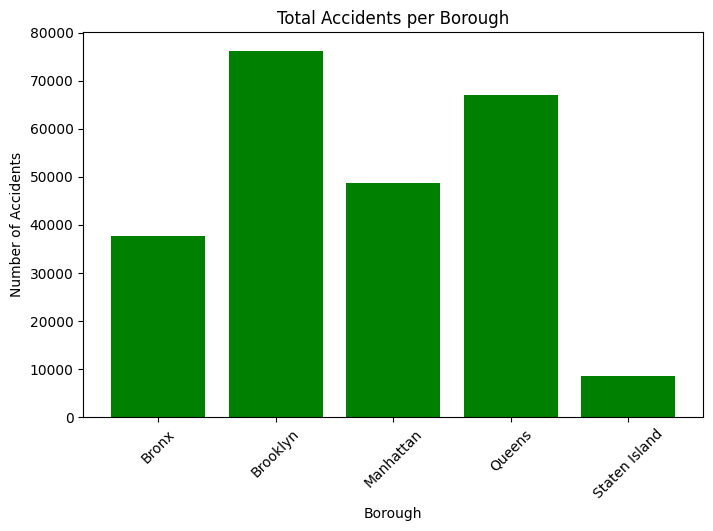

In [ ]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution


plt.figure(figsize=(8, 5))
plt.bar(accidents_by_borough['borough'], accidents_by_borough['total_accidents'], color='green')
plt.title('Total Accidents per Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()


##### 7.2.2

What do you notice in the plot?


**Your answer here**.

I have noticed that Brooklyn and Queens had more no.of accidents

#### 7.3 (hard)

How about per square mile? Calculate the number accidents per square mile for each borough.

**Hint:** You will have to update the keys in the borough dictionary to match the names in the DataFrame.

merging will not done if either of both files are not in proper dataframe
here the borough_data file is in json formate, which is neasted dictionary ( semi-structured data)
so i imported json_normalize to normalise the json file, where it turns into a proper flat DataFrame where each field becomes its own column.

i created a loop where iterate over each borough key string and creates a datalist 
'borough': b.title().replace('The ', ''),  in each iterate this removes ' the' for each key and 
makes the title Normalizes borough names into a standard, readable format that likely matches the borough column in  accident df.


 df_borough = pd.DataFrame(data_list) converted the datalist into a dataframe 

then i have used left join to merge both the dataframes,
it Keeps all rows from the left DataFrame (df), and only bring in matching data from the right DataFrame (df_borough)


In [ ]:
def ex_7_3(df, borough_data):
    """
    Calculate accidents per sq mile for each borough
    
    Arguments:
    `borough_frame`: A pandas DataFrame with the count of accidents per borough
    `borough_data`: A python dictionary with population and area data for each borough
    
    
    Outputs:
    `borough_frame`: The same `borough_frame` DataFrame used as input, only with an
    additional column called `accidents_per_sq_mi` that results from dividing
    the number of accidents in each borough by its area. Please call this new column
    exactly `accidents_per_sq_mi` - otherwise the test cells will throw an error.
    """
    
    #boroughs = ex_7_1(df)
    #borough_frame = pd.DataFrame(boroughs)
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    
    #return borough_frame # This must be a DataFrame, NOT a Series
###########################################################################    

from pandas import json_normalize

json_file = pd.json_normalize(borough_data)
#print(json_file.head())

borough = ['the bronx', 'brooklyn', 'manhattan', 'queens', 'staten island']
data_list = []

for b in borough:
    data_list.append({
        'borough': b.title().replace('The ', ''),  
        'population': json_file[f'{b}.population'][0],
        'area': json_file[f'{b}.area'][0]
    })


df_borough = pd.DataFrame(data_list)
#print(df_borough)


df_merged = pd.merge(
    df,
    df_borough,
    how='left',
    left_on='borough',
    right_on='borough'
)




.str.strip().str.title() removed any extra spaces and captalize the 1st letter of each word so that it matches the coloumn names for both the dataframes
here am dropping the coloumn area before merging to aviod conflicts
am merging the coloumns borough and area, here am using left joi to do merge 
so it finds the matching rows where the borough values are the same

In [ ]:
accidents_by_borough['borough'] = accidents_by_borough['borough'].str.strip().str.title()
df_borough['borough'] = df_borough['borough'].str.strip().str.title()


if 'area' in accidents_by_borough.columns:
    accidents_by_borough = accidents_by_borough.drop(columns=['area'])



accidents_by_borough = accidents_by_borough.merge(
    df_borough[['borough', 'area']],
    on='borough',
    how='left'
)


accidents_by_borough['accidents_per_sq_mile'] = (
    accidents_by_borough['total_accidents'] / accidents_by_borough['area']
)
print(accidents_by_borough)


         borough  total_accidents    area  accidents_per_sq_mile
0          Bronx            37709   42.10             895.700713
1       Brooklyn            76253   70.82            1076.715617
2      Manhattan            48749   22.83            2135.304424
3         Queens            67120  108.53             618.446512
4  Staten Island             8691   58.37             148.894980


#### 7.4
##### 7.4.1

Plot a bar graph of the accidents per square mile per borough with the data you just calculated. 

         borough  total_accidents    area  accidents_per_sq_mile
0          Bronx            37709   42.10             895.700713
1       Brooklyn            76253   70.82            1076.715617
2      Manhattan            48749   22.83            2135.304424
3         Queens            67120  108.53             618.446512
4  Staten Island             8691   58.37             148.894980


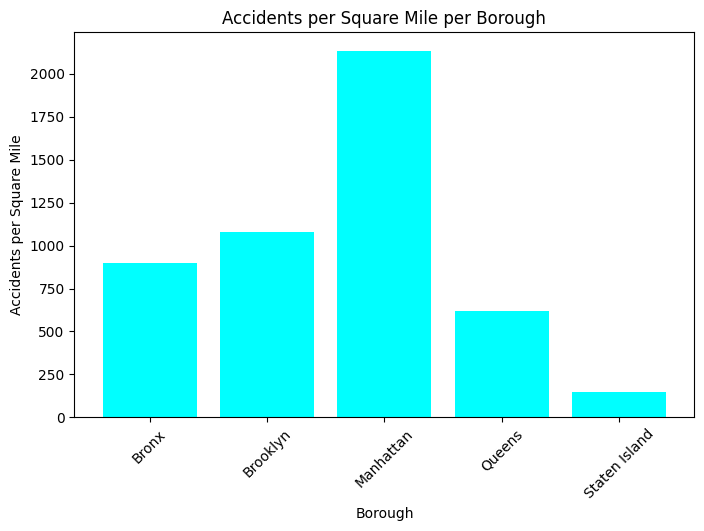

In [ ]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution

print(accidents_by_borough.head())

plt.figure(figsize=(8,5))
plt.bar(accidents_by_borough['borough'], accidents_by_borough['accidents_per_sq_mile'], color='cyan')
plt.title('Accidents per Square Mile per Borough')
plt.xlabel('Borough')
plt.ylabel('Accidents per Square Mile')
plt.xticks(rotation=45)
plt.show()


##### 7.4.2

What can you conclude?


**Your answer here**.


Highest accident density: Manhattan (2,135.3 per sq mile)
Lowest accident density: Staten Island (148.9 per sq mile)

Even though Brooklyn has the most total accidents, Manhattan is much smaller in area, so the density of accidents is highest in Manhattan.
Bronx has a moderate density (895.7), higher than Queens (618.4) despite having fewer total accidents.
Staten Island is both low in total accidents and low in density — safest borough relative to area.

### Exercise 8

#### 8.1

Create a Series of the number of accidents per hour and borough.

here i turned the MultiIndex Series into a regular DataFrame helps in plotting


In [ ]:
def ex_8_1(df):
    """
    Calculate accidents per hour for each borough
    
    Arguments:
    `df`: A pandas DataFrame
    
    
    Outputs:
    `bor_hour`: A Series. This should be the result of doing groupby by borough
    and hour.
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    #return bor_hour
##########################################################

accidents_per_hour_borough = df.groupby(['borough', 'hour']).size()
#print(accidents_per_hour_borough)

accidents_df = accidents_per_hour_borough.reset_index(name='accidents')
print(accidents_df)


           borough  hour  accidents
0            BRONX     0       1329
1            BRONX     1        529
2            BRONX     2        402
3            BRONX     3        361
4            BRONX     4        418
..             ...   ...        ...
115  STATEN ISLAND    19        415
116  STATEN ISLAND    20        367
117  STATEN ISLAND    21        268
118  STATEN ISLAND    22        224
119  STATEN ISLAND    23        174

[120 rows x 3 columns]


#### 8.2
##### 8.2.1

Plot a bar graph for each borough showing the number of accidents for each hour of the day. 

here i Loop through each borough
plt.tight_layout() it is a Matplotlib function that automatically adjusts the spacing between subplots so that labels, titles, and axes don’t overlap.
plt.subplot(len(boroughs), 1, i), Selects subplot for this borough
borough_data = accidents_df[accidents_df['borough'] == borough],This line filters the DataFrame for only one borough at a time.

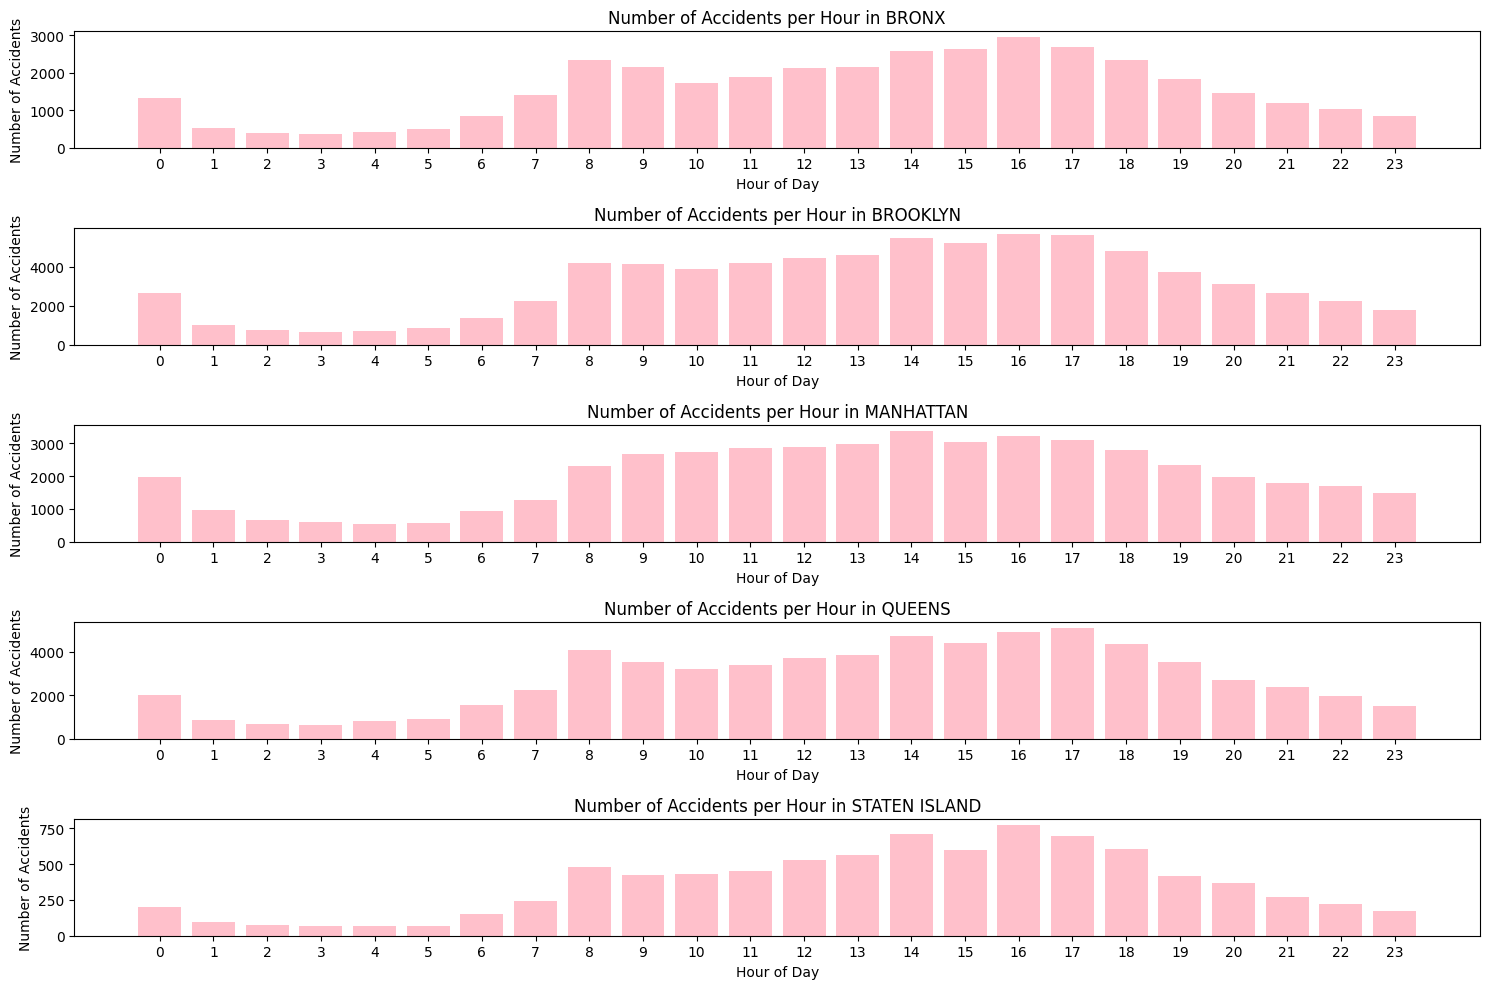

In [ ]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution


plt.figure(figsize=(15, 10))

for i, borough in enumerate(boroughs, 1):
    plt.subplot(len(boroughs), 1, i)
    borough_data = accidents_df[accidents_df['borough'] == borough]
    plt.bar(borough_data['hour'], borough_data['accidents'], color='pink')
    plt.title(f'Number of Accidents per Hour in {borough}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Accidents')
    plt.xticks(range(0, 24))  

plt.tight_layout()
plt.show()


##### 8.2.2

Which hours have the most accidents for each borough?

**Hint:** You can use ```sns.FacetGrid``` to create a grid of plots with the hourly data of each borough.


here i did Groupby borough and hour to find the maximum accidents for each hour in each borough

In [ ]:

peak_hours = accidents_df.loc[accidents_df.groupby('borough')['accidents'].idxmax()]
print(peak_hours[['borough', 'hour', 'accidents']])


           borough  hour  accidents
16           BRONX    16       2952
40        BROOKLYN    16       5701
62       MANHATTAN    14       3375
89          QUEENS    17       5104
112  STATEN ISLAND    16        775


here i imported seaborn to plot facetgrid 
col_wrap=2, it Arranges subplots into 2 columns, sends if any additional plots to the next row
sharey=False, Each subplot gets its own y-axis scale instead of sharing the same for all boroughs

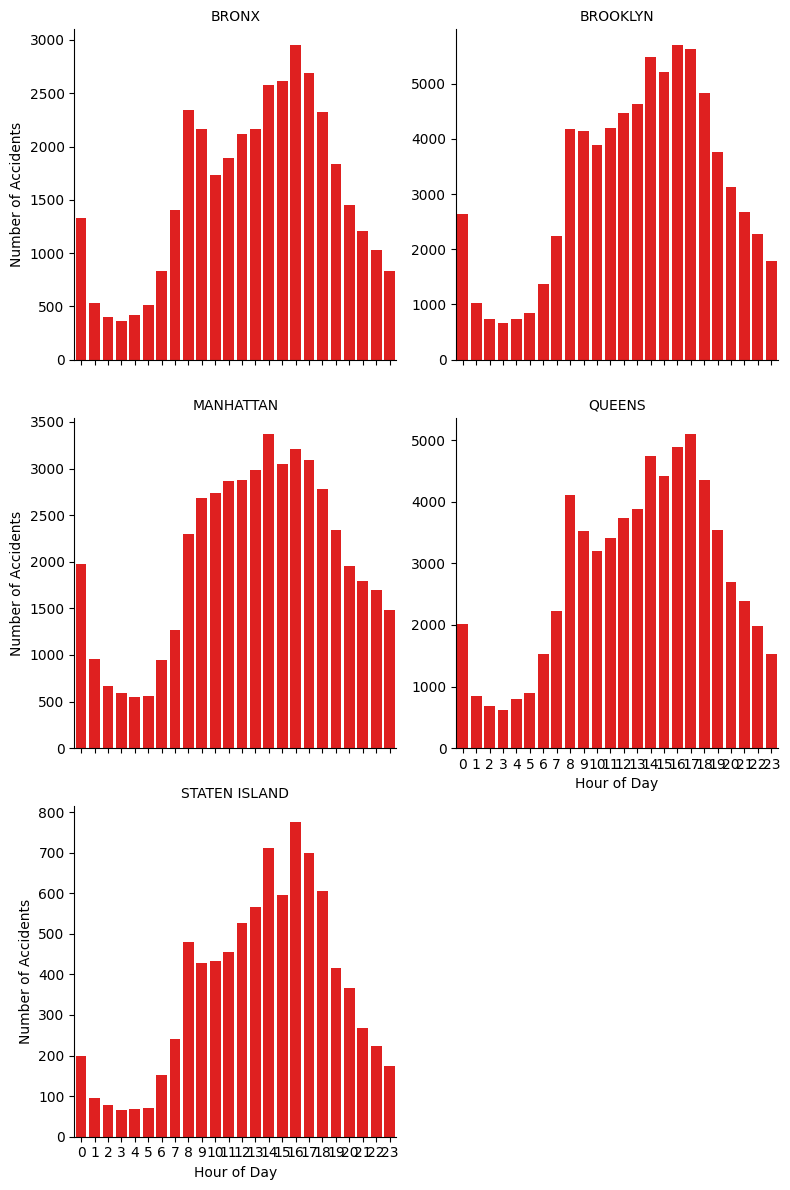

In [ ]:
import seaborn as sns

g = sns.FacetGrid(accidents_df, col="borough", col_wrap=2, height=4, sharey=False)
g.map_dataframe(sns.barplot, x="hour", y="accidents", color="red")
g.set_axis_labels("Hour of Day", "Number of Accidents")
g.set_titles("{col_name}")
g.set(xticks=range(0, 24))
plt.tight_layout()
plt.show()


**Your answer here**.

### Exercise 9 (hard)

Using `contrib_df`, find which 6 factors cause the most accidents. It is important that you avoid double counting the contributing factors of a single accident.

**Hint:** You can use the [**`pd.melt()`**](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) function to take a subset of `df` and convert it from [wide format to narrow format](https://en.wikipedia.org/wiki/Wide_and_narrow_data).

contributing_factor_vehicle' in col, finding the contributing_factor coloumns and saved them as factors_most_acc
df[['collision_id'] + factors_most_acc, unique identifier for each accident]

pd.melt, converts contrib_df from wide format to long format
value_vars=factors_most_acc, value_name='factor', columns i want to “melt” into a single column called factor

Removed NaNs and duplicate values per accident

i did groupby('factor'), which groups the data by each factor.
['collision_id'].nunique(), it counts how many unique accidents each factor appears in.

sort_values(by='num_accidents', ascending=False), this will sorts factors by number of accidents in descending order.


In [ ]:
def ex_9(df):
    """
    Finds which 6 factors cause the most accidents, without 
    double counting the contributing factors of a single accident.
    
    Arguments:
    `contrib_df`: A pandas DataFrame.
    
    Outputs:
    `factors_most_acc`: A pandas DataFrame. It has only 6 elements, which are,
    sorted in descending order, the contributing factors with the most accidents.
    The column with the actual numbers is named `index`.    
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    #return factors_most_acc
############################################################################


factors_most_acc = [col for col in df.columns if 'contributing_factor_vehicle' in col]
contrib_df = df[['collision_id'] + factors_most_acc]


melted = pd.melt(contrib_df,
                 id_vars=['collision_id'],
                 value_vars=factors_most_acc,
                 value_name='factor')


melted = melted.dropna()
melted = melted.drop_duplicates(subset=['collision_id', 'factor'])


factor_counts = melted.groupby('factor')['collision_id'].nunique().reset_index()
factor_counts = factor_counts.rename(columns={'collision_id': 'num_accidents'})


top_6_factors = factor_counts.sort_values(by='num_accidents', ascending=False).head(6)
print(top_6_factors)



                            factor  num_accidents
50                     Unspecified         190096
8   Driver Inattention/Distraction          61752
14   Failure to Yield Right-of-Way          19641
17           Following Too Closely          17293
4                 Backing Unsafely          14835
31             Passing Too Closely          12631


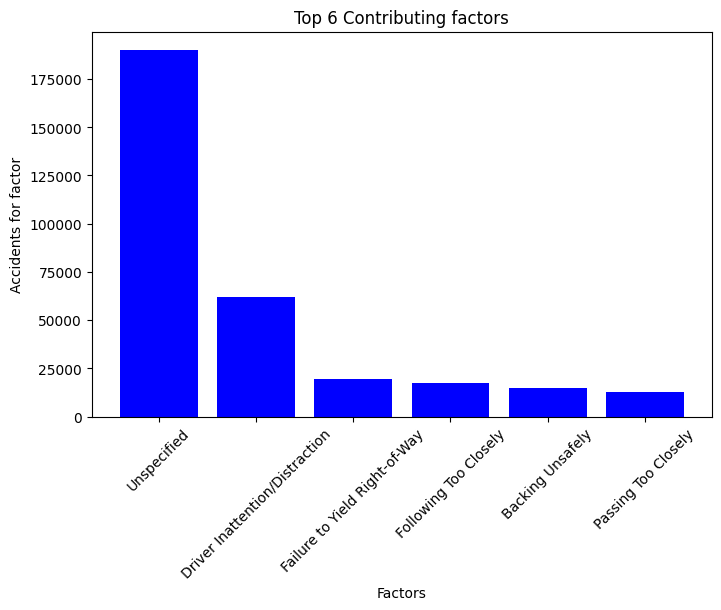

In [57]:
plt.figure(figsize=(8,5))
plt.bar(top_6_factors['factor'], top_6_factors['num_accidents'], color='blue')
plt.title('Top 6 Contributing factors')
plt.xlabel('Factors')
plt.ylabel('Accidents for factor')
plt.xticks(rotation=45)
plt.show()

### Exercise 10 (hard)

Which 10 vehicle type-borough pairs are most involved in accidents? Avoid double counting the types of vehicles involved in a single accident. You can apply a similar approach to the one used in the previous exercise using `pd.melt()`.

**Hint:** You may want to include `BOROUGH` as one of your `id_vars` (the other being `index`) in `pd.melt()`. Including `BOROUGH` in your final `.groupby()` is also a good idea.

vehicle_cols, combined all vehicle _types into a single coloumn

df[['borough'] + vehicle_cols], this selects only the borough column and all vehicle columns.
.copy(), used not to modify the original DataFrame.
df_vehicles['collision_id'] = df_vehicles.index,  assigns a unique ID for each accident.


In [58]:
def ex_10(df):
    """
    Finds the 10 borough:vehicle type pairs with more accidents, without 
    double counting the vehicle types of a single accident.
    
    Arguments:
    `df`: A pandas DataFrame.
    
    Outputs:
    `vehi_most_acc`: A pandas DataFrame. It has only 10 elements, which are,
    sorted in descending order, the borough-vehicle pairs with the most accidents.
    The column with the actual numbers is named `index`
    """

    #vehi_cols = ['VEHICLE TYPE CODE 1','VEHICLE TYPE CODE 2','VEHICLE TYPE CODE 3','VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 5']
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    #return vehi_most_acc
########################################################################


vehicle_cols = ['vehicle_type_code_1','vehicle_type_code_2','vehicle_type_code_3','vehicle_type_code_4','vehicle_type_code_5']


df_vehicles = df[['borough'] + vehicle_cols].copy()
df_vehicles['collision_id'] = df_vehicles.index  

melted = df_vehicles.melt(id_vars=['borough', 'collision_id'],
                          value_vars=vehicle_cols,
                          var_name='vehicle_number',
                          value_name='vehicle_type')


unique_vehicles = melted.drop_duplicates(subset=['collision_id', 'borough', 'vehicle_type'])

top_vehicle_borough = (unique_vehicles
                       .groupby(['borough', 'vehicle_type'])
                       .size()
                       .reset_index(name='num_accidents')
                       .sort_values(by='num_accidents', ascending=False)
                       .head(10))

print(top_vehicle_borough)


        borough                         vehicle_type  num_accidents
510    BROOKLYN                                Sedan          39459
1161     QUEENS                                Sedan          35103
518    BROOKLYN  Station Wagon/Sport Utility Vehicle          32262
1165     QUEENS  Station Wagon/Sport Utility Vehicle          31647
866   MANHATTAN                                Sedan          20727
181       BRONX                                Sedan          19652
871   MANHATTAN  Station Wagon/Sport Utility Vehicle          16432
185       BRONX  Station Wagon/Sport Utility Vehicle          15434
459    BROOKLYN                    PASSENGER VEHICLE          10177
889   MANHATTAN                                 Taxi           8989


### Exercise 11

In a 2018 [interview](https://www.nytimes.com/2019/01/01/nyregion/traffic-deaths-decrease-nyc.html) with The New York Times, New York's mayor de Blasio stated that "*Vision Zero is clearly working*". That year, the number of deaths in traffic accidents in NYC dropped to a historically low 202. Yet, as reported by [am New York Metro](https://www.amny.com/news/vision-zero-de-blasio-1-30707464/), the number of fatalities has increased by 30% in the first quarter of 2019 compared to the previous year and the number of pedestrians and cyclists injured has not seen any improvement.

Which of the following BEST describes how you would use the provided data to understand what went wrong in the first quarter of 2019? Please explain the reasons for your choice.

<ul>
A. Consider the accidents of the first quarter of 2019. Then, check for the most common causes of accidents where pedestrians and cyclists were involved. Give a recommendation based solely on this information.<br>
B. Create a pair of heat maps of the accidents involving injured/killed pedestrians and cyclists in the first quarter of 2018 and 2019. Compare these two to see if there is any change in the concentration of accidents. In critical areas, study the type of factors involved in the accidents. Give a recommendation to visit these areas to study the problem further.<br>
C. The provided data is insufficient to improve our understanding of the situation.<br>
D. None of the above. (If you choose this, please elaborate on what you would do instead.)<br>
</ul>



**Your answer here**.

I think option B is best because it helps us see patterns in accidents, and its cause. By comparing 2018 and 2019 datasets, we can identify areas where accidents increased. Looking at these “hotspots” shows where pedestrians and cyclists are most at risk. We can also check what factors caused these accidents in those areas. This way, we can understand the problem better and suggest ways to make streets safer.

### Exercise 12 (hard)

#### 12.1

Calculate the number of deaths caused by each type of vehicle.

**Hint 1:** As an example of how to compute vehicle involvement in deaths, suppose two people died in an accident where 5 vehicles were involved, and 4 are PASSENGER VEHICLE and 1 is a SPORT UTILITY/STATION WAGON. Then we would add two deaths to both the PASSENGER VEHICLE and SPORT UTILITY/STATION WAGON types.)

**Hint 2:** You will need to use `pd.melt()` and proceed as in the previous exercises to avoid double-counting the types of vehicles (i.e. you should remove duplicate "accident ID - vehicle type" pairs).

In [59]:
def ex_12(df):
    """
    Calculate total killed per vehicle type and plot the result
    as a bar graph
    
    Arguments:
    `df`: A pandas DataFrame.    
    
    Outputs:
    `result`: A pandas DataFrame. Its index should be the vehicle type. Its only
    column should be `TOTAL KILLED`
    """
    
    # YOUR CODE HERE
    #raise NotImplementedError() # Remove this line when you enter your solution
    #return result


vehicle_cols = ['vehicle_type_code_1','vehicle_type_code_2','vehicle_type_code_3','vehicle_type_code_4','vehicle_type_code_5']
killed_cols = ['number_of_pedestrians_killed','number_of_cyclist_killed','number_of_motorist_killed']

df['total_deaths'] = df[killed_cols].sum(axis=1)


df_vehicles = df[['collision_id'] + vehicle_cols + ['total_deaths']].copy()


melted = df_vehicles.melt(
    id_vars=['collision_id', 'total_deaths'],
    value_vars=vehicle_cols,
    var_name='vehicle_number',
    value_name='vehicle_type'
)


melted = melted.drop_duplicates(subset=['collision_id', 'vehicle_type'])

deaths_by_vehicle = melted.groupby('vehicle_type')['total_deaths'].sum().reset_index()
deaths_by_vehicle = deaths_by_vehicle.sort_values(by='total_deaths', ascending=False)


print(deaths_by_vehicle.head(10))



                            vehicle_type  total_deaths
405  Station Wagon/Sport Utility Vehicle            87
395                                Sedan            65
289                           Motorcycle            22
318                    PASSENGER VEHICLE            21
381        SPORT UTILITY / STATION WAGON            20
61                                  Bike            19
69                                   Bus            10
340                        Pick-up Truck             8
64                             Box Truck             8
436                                 Taxi             5


#### 12.2
##### 12.2.1

Plot a bar chart for the top 5 vehicles.

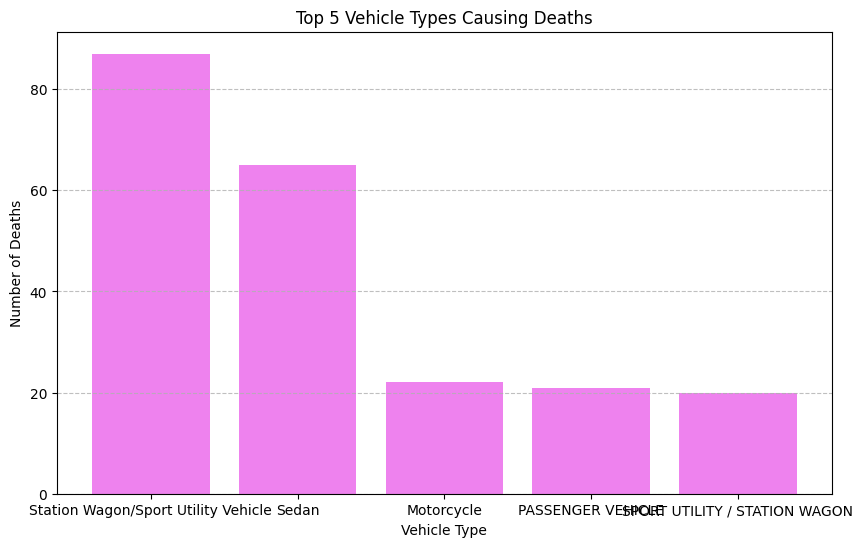

In [72]:
# YOUR CODE HERE
#raise NotImplementedError() # Remove this line when you enter your solution


top5 = deaths_by_vehicle.head(5)
plt.figure(figsize=(10,6))
plt.bar(top5['vehicle_type'], top5['total_deaths'], color='violet')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Deaths')
plt.title('Top 5 Vehicle Types Causing Deaths')
plt.grid(axis='y', linestyle='--', alpha=0.8) 
plt.show()


##### 12.2.2

Which vehicles are most often involved in deaths, and by how much more than the others?


Station Wagon / SUV is the vehicle type mostly involved in deaths, with 87 deaths.
Sedans come second with 65 deaths, which is 22 fewer deaths than SUVs.

After the top two, the deaths drop sharply:
Motorcycles: 22
Passenger Vehicles: 21
SUVs again (slightly different category): 20
So the top 2 vehicle types (SUVs and Sedans) as a much larger share of deaths than all other types of vehicles ,around twice or more than motorcycles, bikes, or buses.

**Your answer here**.

## Testing cells

In [73]:
# Ex. 2
assert type(ex_2(df)) == type(pd.Series([9,1,2])), "Ex. 2 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default."
assert ex_2(df).loc["2018-10"] == 13336, "Ex. 2 - Wrong output! Try using the .size() aggregation function with your .groupby()."
print("Exercise 2.1 looks correct!")

AssertionError: Ex. 2 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default.

In [ ]:
# Ex 4
assert type(ex_4(df)) == type(pd.Series([9,1,2])), "Ex. 4 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default."
assert ex_4(df).loc[13] == 14224, "Ex. 4 - Wrong output! Try using the .size() aggregation function with your .groupby()."
print("Exercise 4.1 looks correct!")

AssertionError: Ex. 4 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default.

In [ ]:
# Ex. 6
assert type(ex_6(df)) == type(pd.Series([9,1,2])), "Ex. 6 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default."
assert max(ex_6(df)) == 37886, "Ex. 6 - Your results don't match ours! Remember that you can use the .size() aggregation function to count the number of elements in a groupby group."
print("Exercise 6.1 looks correct!")

In [ ]:
# Ex. 7.1
assert type(ex_7_1(df)) == type(pd.Series([9,1,2])), "Ex. 7.1 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default."
assert max(ex_7_1(df)) == 76253, "Ex. 7.1 - Your results don't match ours! Remember that you can use the .size() aggregation function to count the number of elements in a groupby group."
print("Exercise 7.1 looks correct!")

In [ ]:
# Ex. 7.3
with open('data/borough_data.json') as f:
    borough_data=json.load(f)
borough_data
e73 = ex_7_3(df, borough_data)
assert "accidents_per_sq_mi" in e73.columns, "Ex. 7.3 - You didn't create an 'accidents_per_sq_mi' in your DataFrame!"
assert round(min(e73["accidents_per_sq_mi"])) == 149, "Ex. 7.3 - Your output doesn't match ours! Remember that you need to divide the number of accidents in each of the five boroughs by the respective areas in square miles."
print("Exercise 7.3 looks correct!")

In [ ]:
# Ex. 8.1
assert type(ex_8_1(df)) == type(pd.Series([9,1,2])), "Ex. 9 - Your output isn't a pandas Series. If you use .groupby(), it outputs a Series by default."
assert ex_8_1(df).max() == 5701, "Ex. 8.1 - Your numbers don't match ours. If you haven't already, you can try using .size() as your aggregation function."
print("Exercise 8.1 looks correct!")

In [ ]:
# Ex. 9
assert type(ex_9(df)) == type(pd.Series([9,1,2]).to_frame()), "Ex. 9 - Your output isn't a pandas DataFrame. If you use .groupby(), it outputs a Series by default."
assert len(ex_9(df)) == 6, "Ex. 9 - Your output doesn't have six elements. Did you forget to use .head(6)?"
assert int(ex_9(df).sum()) == 316248, "Ex. 9 - Your numbers don't match ours. Are you sure you sorted your Series in descending order? If you haven't already, you can try using .count() as your aggregation function."
print("Exercise 9 looks correct!")

In [ ]:
# Ex. 10
assert type(ex_10(df)) == type(pd.Series([9,1,2]).to_frame()), "Ex. 10 - Your output isn't a pandas DataFrame. If you use .groupby(), it outputs a Series by default."
assert len(ex_10(df)["index"]) == 10, "Ex. 10 - Your output doesn't have 10 elements. Did you forget to use .head(10)?"
assert ex_10(df)["index"].sum() == 229882, "Ex. 10 - Your numbers don't match ours. Are you sure you sorted your Series in descending order? If you haven't already, you can try using .count() as your aggregation function."
print("Exercise 10 looks correct!")

In [ ]:
# Ex. 12
e12 = ex_12(df)
assert type(e12) == type(pd.Series([9,1,2]).to_frame()), "Ex. 12 - Your output isn't a pandas DataFrame. If you use .groupby(), it outputs a Series by default."
assert int(e12.loc["Bike"]) == 19, "Ex. 12 - Your output doesn't match ours! Remember that you need to remove the duplicate pairs and use the .sum() aggregation function in your groupby."
print("Exercise 12.1 looks correct!")

## Attribution

"Vehicle Collisions in NYC 2015-Present", New York Police Department, [NYC Open Data terms of use](https://opendata.cityofnewyork.us/overview/#termsofuse), https://www.kaggle.com/nypd/vehicle-collisions

"Boroughs of New York City", Creative Commons Attribution-ShareAlike License, https://en.wikipedia.org/wiki/Boroughs_of_New_York_City